# Introduction
This is the notebook exploration for the cox_violent_parsed_filt file

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
cox_filt = pd.read_csv("../data/cox-violent-parsed_filt.csv")
cox_filt.head()

,id,name,first,last,sex,dob,age,age_cat,race,juv_fel_count,...,vr_charge_desc,type_of_assessment,decile_score.1,score_text,screening_date,v_type_of_assessment,v_decile_score,v_score_text,priors_count.1,event
0,1.0,miguel hernandez,miguel,hernandez,Male,18/04/1947,69,Greater than 45,Other,0,...,NaN,Risk of Recidivism,1,Low,14/08/2013,Risk of Violence,1,Low,0,0
1,2.0,miguel hernandez,miguel,hernandez,Male,18/04/1947,69,Greater than 45,Other,0,...,NaN,Risk of Recidivism,1,Low,14/08/2013,Risk of Violence,1,Low,0,0
2,3.0,michael ryan,michael,ryan,Male,06/02/1985,31,25 - 45,Caucasian,0,...,NaN,Risk of Recidivism,5,Medium,31/12/2014,Risk of Violence,2,Low,0,0
3,4.0,kevon dixon,kevon,dixon,Male,22/01/1982,34,25 - 45,African-American,0,...,Felony Battery (Dom Strang),Risk of Recidivism,3,Low,27/01/2013,Risk of Violence,1,Low,0,1
4,5.0,ed philo,ed,philo,Male,14/05/1991,24,Less than 25,African-American,0,...,NaN,Risk of Recidivism,4,Low,14/04/2013,Risk of Violence,3,Low,4,0


In [3]:
cox_filt.describe()

,id,age,juv_fel_count,decile_score,juv_misd_count,juv_other_count,priors_count,days_b_screening_arrest,c_days_from_compas,is_recid,r_days_from_arrest,violent_recid,is_violent_recid,decile_score.1,v_decile_score,priors_count.1,event
count,11001.00000,18316.000000,18316.000000,18316.000000,18316.000000,18316.000000,18316.000000,17019.000000,17449.000000,18316.000000,6359.000000,0.0,18316.000000,18316.000000,18316.000000,18316.000000,18316.000000
mean,5501.00000,34.019273,0.076873,4.997052,0.098439,0.124263,3.913191,4.302485,57.694596,0.414774,19.961629,NaN,0.073105,4.997052,4.022822,3.913191,0.044715
std,3175.85949,11.667811,0.464272,2.937569,0.517639,0.524537,5.299864,81.159881,317.994694,0.576449,74.139695,NaN,0.260317,2.937569,2.614189,5.299864,0.206683
min,1.00000,18.000000,0.000000,-1.000000,0.000000,0.000000,0.000000,-597.000000,0.000000,-1.000000,-1.000000,NaN,0.000000,-1.000000,-1.000000,0.000000,0.000000
25%,2751.00000,25.000000,0.000000,2.000000,0.000000,0.000000,0.000000,-1.000000,1.000000,0.000000,0.000000,NaN,0.000000,2.000000,2.000000,0.000000,0.000000
50%,5501.00000,31.000000,0.000000,5.000000,0.000000,0.000000,2.000000,-1.000000,1.000000,0.000000,0.000000,NaN,0.000000,5.000000,4.000000,2.000000,0.000000
75%,8251.00000,41.000000,0.000000,8.000000,0.000000,0.000000,5.000000,0.000000,2.000000,1.000000,1.000000,NaN,0.000000,8.000000,6.000000,5.000000,0.000000
max,11001.00000,96.000000,20.000000,10.000000,13.000000,17.000000,43.000000,1057.000000,9485.000000,1.000000,993.000000,NaN,1.000000,10.000000,10.000000,43.000000,1.000000


In [4]:
print(cox_filt.shape)
cox_filt.dtypes

(18316, 40)


id                         float64
name                        object
first                       object
last                        object
sex                         object
dob                         object
age                          int64
age_cat                     object
race                        object
juv_fel_count                int64
decile_score                 int64
juv_misd_count               int64
juv_other_count              int64
priors_count                 int64
days_b_screening_arrest    float64
c_jail_in                   object
c_jail_out                  object
c_days_from_compas         float64
c_charge_degree             object
c_charge_desc               object
is_recid                     int64
r_charge_degree             object
r_days_from_arrest         float64
r_offense_date              object
r_charge_desc               object
r_jail_in                   object
violent_recid              float64
is_violent_recid             int64
vr_charge_degree    

In [5]:
cox_filt.columns

Index(['id', 'name', 'first', 'last', 'sex', 'dob', 'age', 'age_cat', 'race',
       'juv_fel_count', 'decile_score', 'juv_misd_count', 'juv_other_count',
       'priors_count', 'days_b_screening_arrest', 'c_jail_in', 'c_jail_out',
       'c_days_from_compas', 'c_charge_degree', 'c_charge_desc', 'is_recid',
       'r_charge_degree', 'r_days_from_arrest', 'r_offense_date',
       'r_charge_desc', 'r_jail_in', 'violent_recid', 'is_violent_recid',
       'vr_charge_degree', 'vr_offense_date', 'vr_charge_desc',
       'type_of_assessment', 'decile_score.1', 'score_text', 'screening_date',
       'v_type_of_assessment', 'v_decile_score', 'v_score_text',
       'priors_count.1', 'event'],
      dtype='object')

In [6]:
cox_filt['race'].value_counts()

race
African-American    9791
Caucasian           6086
Hispanic            1451
Other                860
Asian                 71
Native American       57
Name: count, dtype: int64

Total Records by Race:
race
African-American    9791
Caucasian           6086
Hispanic            1451
Other                860
Asian                 71
Native American       57
Name: count, dtype: int64

False Positive Rate by Race (%):
race
African-American    11.377796
Caucasian            5.422281
Hispanic             5.720193
Other                1.627907
Asian                4.225352
Native American      1.754386
Name: count, dtype: float64

Combined Data:
                  Total Records  False Positives  False Positive Rate (%)
race                                                                     
African-American           9791             1114                11.377796
Caucasian                  6086              330                 5.422281
Hispanic                   1451               83                 5.720193
Other                       860               14                 1.627907
Asian                        71                3                 4.225352
Native American

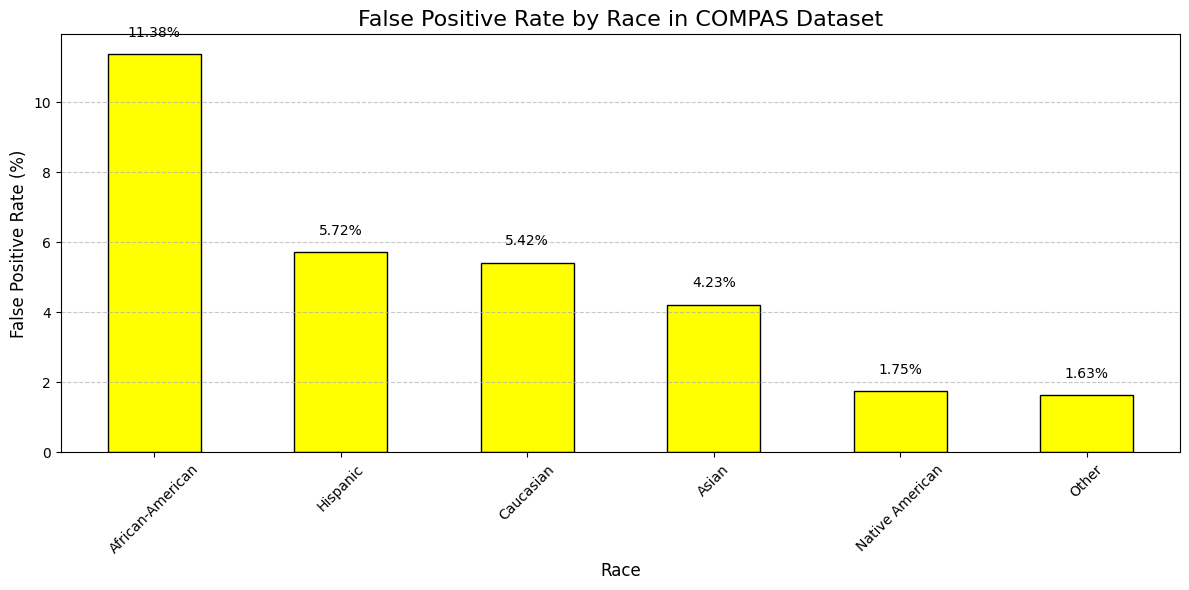

In [8]:
# Total records for each race
total_predictions_by_race = cox_filt['race'].value_counts()

# False Positives: Predicted High Risk but did not recidivate (`is_recid` == 0)
false_positives = cox_filt[(cox_filt['score_text'] == 'High') & (cox_filt['is_recid'] == 0)]
fp_race_counts = false_positives['race'].value_counts()

# Calculate false positive rate by race
fp_rate_by_race = (fp_race_counts / total_predictions_by_race) * 100

# Display the total records and false positive rates
print("Total Records by Race:")
print(total_predictions_by_race)
print("\nFalse Positive Rate by Race (%):")
print(fp_rate_by_race)

# Combine both metrics into a single DataFrame for better visualization
combined_data = pd.DataFrame({
    "Total Records": total_predictions_by_race,
    "False Positives": fp_race_counts,
    "False Positive Rate (%)": fp_rate_by_race
}).fillna(0)  # Fill NaN values with 0 for races with no false positives

print("\nCombined Data:")
print(combined_data)

# Plot the false positive rate by race
plt.figure(figsize=(12, 6))
fp_rate_by_race.sort_values(ascending=False).plot(kind='bar', color='yellow', edgecolor='black')

# Add labels and title
plt.title('False Positive Rate by Race in COMPAS Dataset', fontsize=16)
plt.xlabel('Race', fontsize=12)
plt.ylabel('False Positive Rate (%)', fontsize=12)
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Annotate bars with values
for index, value in enumerate(fp_rate_by_race.sort_values(ascending=False)):
    plt.text(index, value + 0.5, f"{value:.2f}%", ha='center', fontsize=10)

# Show the plot
plt.tight_layout()